# Spam Email Classifier

## Week 3 - TF-IDF and Naive Bayes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [9]:
df = pd.read_csv("../dataset/cleaned_spam_email.csv")

In [10]:
df.head()

,from,to,subject,date,body,label
0,robert elz <kre@munnari.oz.au>,chris garrigues <cwg-dated-1030377287.06fa6d@d...,re: new sequences window,2002-08-22 11:26:25+00:00,"date: wed, 21 aug 2002 10:54:46 -0500\n...",0
1,steve burt <steve_burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...",[zzzzteana] re: alexander,2002-08-22 11:46:18+00:00,"martin a posted:\ntassos papadopoulos, the gre...",0
2,tim chapman <timc@2ubh.com>,zzzzteana <zzzzteana@yahoogroups.com>,[zzzzteana] moscow bomber,2002-08-22 12:52:38+00:00,man threatens explosion in moscow \n\nthursday...,0
3,monty solomon <monty@roscom.com>,undisclosed-recipient:;,[irr] klez: the virus that won't die,2002-08-22 13:15:25+00:00,klez: the virus that won't die\n \nalready the...,0
4,stewart smith <stewart.smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,re: [zzzzteana] nothing like mama used to make,2002-08-22 13:38:22+00:00,"> in adding cream to spaghetti carbonara, whi...",0


In [11]:
df["label"].value_counts()

label
0    2498
1     468
Name: count, dtype: int64

In [12]:
X = df["body"]
y = df["label"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

In [15]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [16]:
X_test_tfidf = vectorizer.transform(X_test)

In [17]:
model = MultinomialNB()

In [18]:
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[1998., 374.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.17,-1.85]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[49.73, 8.84, 2.23,..., 0. , 0.1 , 0. ], [ 2.54, 9.1 , 0. ,..., 0.27, 2.09, 0.3 ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-5.83,-7.47,-8.59,...,-9.76,-9.67,-9.76], [-7.64,-6.6 ,-8.91,...,-8.67,-7.78,-8.65]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [19]:
y_pred = model.predict(X_test_tfidf)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9629629629629629


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       500
           1       1.00      0.77      0.87        94

    accuracy                           0.96       594
   macro avg       0.98      0.88      0.92       594
weighted avg       0.96      0.96      0.96       594



In [22]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[500   0]
 [ 22  72]]


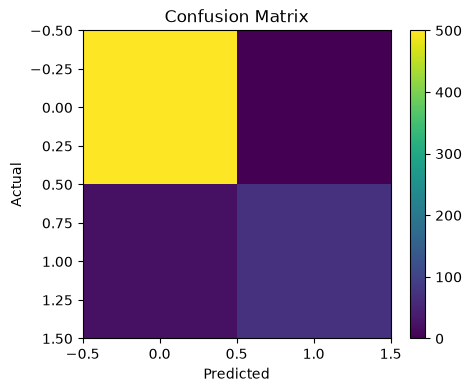

In [23]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [24]:
results = pd.DataFrame({
    "Email": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Email,Actual,Predicted
0,*** free bonus offer - see below ***\n\nwe can...,1,0
1,">>>>> on wed, 9 oct 2002, ""jason"" == jason ren...",0,0
2,dave long writes:\n> > (and no it wasnt me eve...,0,0
3,"reminds me of cheney during the vp debates, wh...",0,0
4,"on wed, 2002-08-28 at 13:57, michael clark wro...",0,0
5,http://www.pressherald.com/news/state/021201mo...,0,0
6,yannick gingras wrote:\n\n> i am wondering ...,0,0
7,"el> on sun, 8 sep 2002, cdale wrote:\n\n>> i a...",0,0
8,today an apt-get upgrade holds back php (and s...,0,0
9,[barry]\n> here's an interesting thing to test...,0,0


In [25]:
joblib.dump(
    vectorizer,
    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']

In [26]:
joblib.dump(
    model,
    "../models/naive_bayes_model.pkl"
)

['../models/naive_bayes_model.pkl']

In [27]:
print("Week 3 spam classifier completed successfully.")

Week 3 spam classifier completed successfully.
